#### Remapping CESM-HR grid to MPAS grid
- read CESM-HR dataset
- read MPAS grid
- regridding
- plotting

Ming Ge April 2025

In [2]:
import numpy as np
import xarray as xr
import scipy.spatial.qhull as qhull
import uxarray as ux
import holoviews as hv
hv.extension("matplotlib")
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [4]:
%%time
# CESM-HR dataset
dir_d = '/Users/mingge/Documents/PythiaWork/code/mpasviewer-cookbook/data/' 
flnm_data = dir_d + 'b.e13.BHISTC5.ne120_t12.cesm-ihesp-hires1.0.46-1920-2005.007.cam.h0.TS.196001-196912.nc'

dir_g = "/Users/mingge/Documents/PythiaWork/code/mpasviewer-cookbook/data/"
flnm_grid = dir_g + "ne120np4_ESMFmesh_cdf5_c20211018.nc"

print('read CESM-HR data')
uxds = ux.open_dataset(flnm_grid, flnm_data)

# MPAS destination grid
flnm_destination_grid = '/Users/mingge/Documents/PythiaWork/code/mpasviewer-cookbook/240km_uniform/x1.10242.static.nc'

print('read MPAS grid')
grid = ux.open_grid(flnm_destination_grid)

ts = uxds["TS"][0]
#ts.shape # (777602,)
#grid

read CESM-HR data
read MPAS grid
CPU times: user 138 ms, sys: 40.5 ms, total: 179 ms
Wall time: 182 ms


In [5]:
%%time
print('remapping')
remapped_grid = uxds["TS"][0].remap.inverse_distance_weighted(
    grid, k=3, remap_to="face centers"
)

remapping
CPU times: user 4.03 s, sys: 463 ms, total: 4.5 s
Wall time: 4.49 s


:Layout
   .Image.I  :Image   [x,y]   (x_y TS)
   .Image.II :Image   [x,y]   (x_y TS)
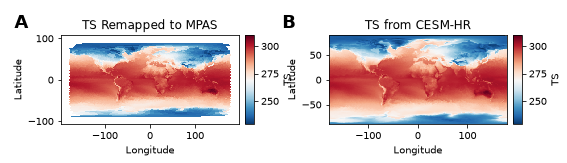

In [6]:
(
    remapped_grid.plot(
    cmap = 'RdBu_r',
    colorbar=True,
    title="TS Remapped to MPAS",
    width=400, height=200, padding=0.1) 
 + 
 uxds["TS"][0].plot(
    cmap = 'RdBu_r',
    colorbar=True,
    title="TS from CESM-HR",
    width=400, height=200)
). cols(2)